In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
from jax.scipy.spatial.transform import Rotation as Rot



import genmetaballs.fmb.fm_render as fm_render
from genmetaballs.core import (
    FMB,
    Intrinsics,
    ThreeParameterBlender,
    ZeroParameterConfidence,
    geometry,
    make_fmb_scene_from_values,
    render_fmbs,
)
from genmetaballs.fmb.utils import DegradeLR, get_camera_rays, image_grid

Pose, Vec3D, Rotation = geometry.Pose, geometry.Vec3D, geometry.Rotation


# JAX setup (before importing)
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
np.random.seed(0)
print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend().upper()}")
print(f"JAX devices: {jax.devices()}")

Running cmake --build & --install in /home/matin/GenMetaBalls/build
JAX version: 0.8.0
JAX backend: GPU
JAX devices: [CudaDevice(id=0)]


In [2]:
height, width = image_size = (64, 80)
focal_length = 2.0
cx = (width - 1) / 2
cy = (height - 1) / 2

In [3]:
# integer xy-coordinates (as opposed to ij coordinates) of the pixels in the image
# augmented with zeros
pixel_list = (
    (np.array(np.meshgrid(np.arange(width), height - np.arange(height) - 1, [0]))[:, :, :, 0])
    .reshape((3, -1))
    .T
)
# camera frame in get_camera rays has -z pointing into the image!!!!
camera_rays = get_camera_rays(focal_length, focal_length, cx, cy, pixel_list)
rays_trans = np.stack(
    [camera_rays, np.tile(np.zeros(3), (camera_rays.shape[0], 1))], 1
)

In [4]:
hyperparams = fm_render.hyperparams
beta2 = jnp.float32(np.exp(hyperparams[0]))
beta3 = jnp.float32(np.exp(hyperparams[1]))

In [5]:
mean = jnp.array([0., 0, -1])
extent = jnp.array([8.0, 4, 1])
# XXX what is rot exactly?
rot = Rot.from_euler('ZYX', jnp.array([jnp.pi/4, 0, 0]))

In [6]:
# reference impl
render_jit = jax.jit(fm_render.render_func_rays)

log_weights = np.zeros(1)
rotmat = rot.as_matrix()
# XXX what the reference impl. calls the "precision matrix" is
# actually the square root of the precision matrix
prec = rotmat @ np.diag(1/jnp.sqrt(extent)) @ rotmat.T
ref_depth, ref_alpha, *_ = render_jit(
    mean[jnp.newaxis, ...], prec[jnp.newaxis, ...], log_weights, rays_trans, beta2, beta3
)

In [7]:
# GenMetaballs
camera = Intrinsics(fx=focal_length, fy=focal_length, cx=cx, cy=cy, width=width, height=height)
campose = geometry.Pose()

fmb = FMB(Pose.from_components(Rotation.from_quat(*rot.as_quat()), Vec3D(*mean)), *extent)
scene = make_fmb_scene_from_values([fmb], list(log_weights), device="gpu")

confidence = ZeroParameterConfidence()
blender = ThreeParameterBlender(beta1=beta3, beta2=beta2, eta=1.0)
image = render_fmbs(scene, blender, confidence, camera, campose)

img_view = image.as_view()
gmb_depth = img_view.depth.as_jax()
gmb_alpha = img_view.confidence.as_jax()

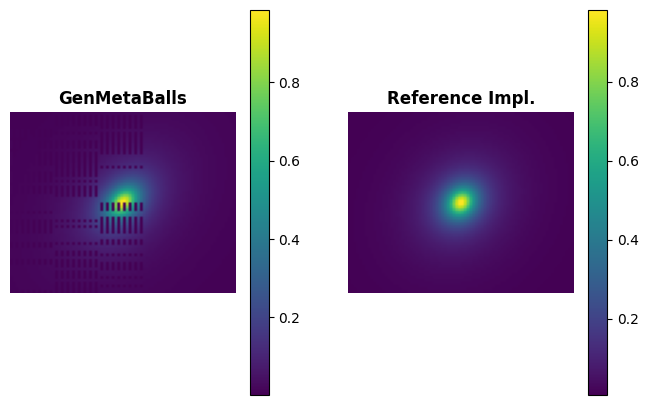

In [8]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8, 5))
im0 = ax0.imshow(gmb_depth)
ax0.set_title("GenMetaBalls", fontsize=12, fontweight="bold")
ax0.axis("off")
plt.colorbar(im0, ax=ax0)

ax1.set_title("Reference Impl.", fontsize=12, fontweight="bold")
im1 = ax1.imshow(ref_depth.reshape(image_size))
ax1.axis("off")
plt.colorbar(im1, ax=ax1)